In [1]:
# Cell 1
!pip install -q torch torchaudio transformers peft librosa panns-inference accelerate soundfile scipy "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 56.2 MB/s eta 0:00:00


In [4]:
# Cell 2 (Modified for 10-second outputs)
import os
import json
import torch
import librosa
import numpy as np
import soundfile as sf
from scipy.io import wavfile
from panns_inference import SoundEventDetection, labels

AUDIO_INPUTS = ["audio1.mp3", "audio2.mp3", "audio3.mp3"]
DATASET_DIR = "./dataset"
BASELINE_DIR = "./baseline_outputs"
FINETUNED_DIR = "./finetuned_outputs"
SAMPLE_RATE_PANNS = 32000
SAMPLE_RATE_MUSICGEN = 32000

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(BASELINE_DIR, exist_ok=True)
os.makedirs(FINETUNED_DIR, exist_ok=True)

for path in AUDIO_INPUTS:
    if not os.path.exists(path):
        dummy_audio = np.zeros(SAMPLE_RATE_PANNS * 60)
        sf.write(path, dummy_audio, SAMPLE_RATE_PANNS)

In [7]:
# Cell 3
device = "cuda" if torch.cuda.is_available() else "cpu"
sed_model = SoundEventDetection(checkpoint_path=None, device=device)
if "Sitar" not in labels:
    raise ValueError("Sitar class not found in PANNs labels")

sitar_class_idx = labels.index("Sitar")

print("Using PANNs Sitar class index:", sitar_class_idx)

Checkpoint path: /root/panns_data/Cnn14_DecisionLevelMax.pth
GPU number: 1
Using PANNs Sitar class index: 148


In [11]:
# Clear old dataset before regenerating clips

import os
import shutil

if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

os.makedirs(DATASET_DIR, exist_ok=True)

print("Old dataset cleared.")

Old dataset cleared.


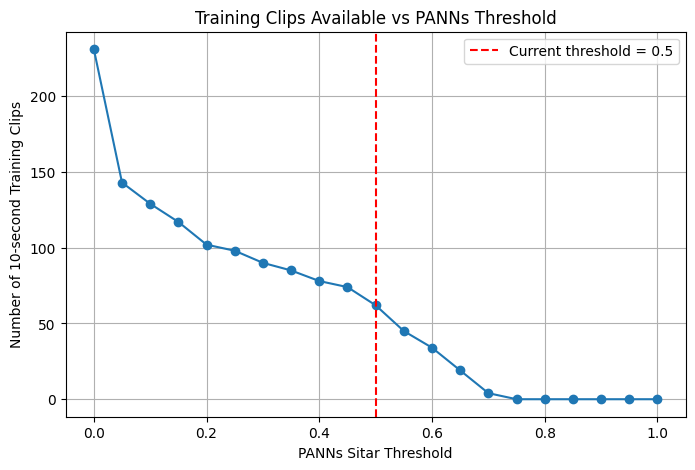

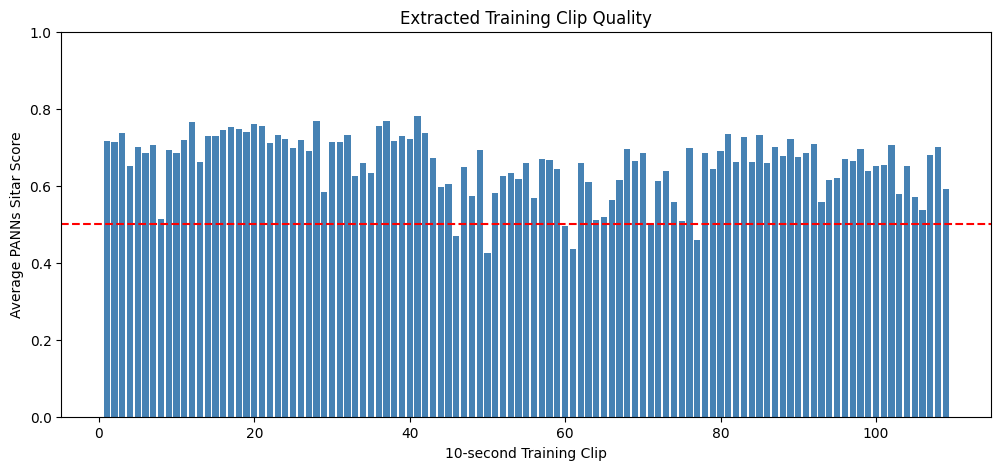

In [12]:
# Cell 4 (10-sec clips + threshold vs number of training clips)

import matplotlib.pyplot as plt

CLIP_DURATION_SEC = 10
SITAR_THRESHOLD = 0.5
MIN_DETECTION_SEC = 5.0

clip_counter = 1

clip_scores = []
clip_labels = []

# Store all audio/frame information for threshold analysis
all_audio_data = []


for audio_path in AUDIO_INPUTS:

    try:
        audio, sr = librosa.load(
            audio_path,
            sr=SAMPLE_RATE_PANNS,
            mono=True
        )

    except Exception:
        continue


    hop_length = 320


    with torch.no_grad():

        audio_tensor = audio[None, :]

        inference_output = sed_model.inference(audio_tensor)


        if isinstance(inference_output, (tuple, list)):
            framewise_output = inference_output[1][0]

        elif isinstance(inference_output, dict):
            framewise_output = inference_output["framewise_output"][0]

        else:
            framewise_output = getattr(
                inference_output,
                "framewise_output",
                inference_output
            )[0]


    sitar_prob = framewise_output[:, sitar_class_idx]


    # Save for threshold sweep
    all_audio_data.append(
        {
            "audio": audio,
            "sitar_prob": sitar_prob,
            "hop_length": hop_length
        }
    )



# ----------------------------------------------------
# Threshold sweep: estimate number of 10-sec clips
# ----------------------------------------------------

thresholds = np.arange(0.0, 1.05, 0.05)

clip_counts = []


for threshold in thresholds:

    count = 0


    for item in all_audio_data:

        sitar_prob = item["sitar_prob"]
        audio = item["audio"]
        hop_length = item["hop_length"]


        detected_indices = np.where(
            sitar_prob > threshold
        )[0]


        if len(detected_indices) == 0:
            continue


        regions = []

        start_frame = detected_indices[0]
        prev_frame = detected_indices[0]


        for frame in detected_indices[1:]:

            if frame == prev_frame + 1:
                prev_frame = frame

            else:
                regions.append(
                    (start_frame, prev_frame)
                )
                start_frame = frame
                prev_frame = frame


        regions.append(
            (start_frame, prev_frame)
        )


        for start_f, end_f in regions:

            start_sec = (
                start_f * hop_length
            ) / SAMPLE_RATE_PANNS

            end_sec = (
                end_f * hop_length
            ) / SAMPLE_RATE_PANNS


            duration = end_sec - start_sec


            if duration < MIN_DETECTION_SEC:
                continue


            region_duration = int(duration)

            # number of 10-sec clips from this region
            count += region_duration // CLIP_DURATION_SEC


    clip_counts.append(count)



plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    clip_counts,
    marker="o"
)

plt.axvline(
    SITAR_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Current threshold = {SITAR_THRESHOLD}"
)

plt.xlabel("PANNs Sitar Threshold")
plt.ylabel("Number of 10-second Training Clips")
plt.title("Training Clips Available vs PANNs Threshold")

plt.grid(True)
plt.legend()

plt.show()



# ----------------------------------------------------
# Actual extraction using chosen threshold
# ----------------------------------------------------

for item in all_audio_data:

    audio = item["audio"]
    sitar_prob = item["sitar_prob"]

    detected_indices = np.where(
        sitar_prob > SITAR_THRESHOLD
    )[0]


    if len(detected_indices) == 0:
        continue


    regions = []

    start_frame = detected_indices[0]
    prev_frame = detected_indices[0]


    for frame in detected_indices[1:]:

        if frame == prev_frame + 1:
            prev_frame = frame

        else:
            regions.append(
                (start_frame, prev_frame)
            )
            start_frame = frame
            prev_frame = frame


    regions.append(
        (start_frame, prev_frame)
    )


    for start_f, end_f in regions:

        start_sec = (
            start_f * 320
        ) / SAMPLE_RATE_PANNS

        end_sec = (
            end_f * 320
        ) / SAMPLE_RATE_PANNS


        if end_sec - start_sec < MIN_DETECTION_SEC:
            continue


        start_sample = int(
            start_sec * SAMPLE_RATE_PANNS
        )

        end_sample = int(
            end_sec * SAMPLE_RATE_PANNS
        )


        region_audio = audio[start_sample:end_sample]


        clip_samples = (
            CLIP_DURATION_SEC *
            SAMPLE_RATE_PANNS
        )


        for offset in range(
            0,
            len(region_audio),
            clip_samples
        ):

            clip = region_audio[
                offset:offset + clip_samples
            ]


            if len(clip) < (
                MIN_DETECTION_SEC *
                SAMPLE_RATE_PANNS
            ):
                continue


            if len(clip) < clip_samples:
                clip = np.pad(
                    clip,
                    (
                        0,
                        clip_samples-len(clip)
                    )
                )


            score_start = (
                start_f +
                int(offset / 320)
            )

            score_end = min(
                score_start +
                int(clip_samples / 320),
                len(sitar_prob)
            )

            clip_score = np.mean(
                sitar_prob[
                    score_start:score_end
                ]
            )


            clip_scores.append(
                clip_score
            )

            clip_labels.append(
                clip_counter
            )


            clip_name = (
                f"clip{clip_counter:03d}.wav"
            )

            sf.write(
                os.path.join(
                    DATASET_DIR,
                    clip_name
                ),
                clip,
                SAMPLE_RATE_PANNS
            )

            clip_counter += 1



# Plot actual extracted clip scores

plt.figure(figsize=(12,5))

plt.bar(
    clip_labels,
    clip_scores,
    color="steelblue"
)

plt.axhline(
    SITAR_THRESHOLD,
    color="red",
    linestyle="--"
)

plt.xlabel("10-second Training Clip")
plt.ylabel("Average PANNs Sitar Score")
plt.title("Extracted Training Clip Quality")

plt.ylim(0,1)

plt.show()

In [13]:
# Cell 5
metadata = {}
dataset_clips = sorted(os.listdir(DATASET_DIR))

if len(dataset_clips) == 0:
    fallback_clip = os.path.join(DATASET_DIR, "clip001.wav")
    sf.write(fallback_clip, np.zeros(SAMPLE_RATE_MUSICGEN * CLIP_DURATION_SEC), SAMPLE_RATE_MUSICGEN)
    dataset_clips = ["clip001.wav"]

for clip_file in dataset_clips:
    if clip_file.endswith(".wav"):
        metadata[clip_file] = "melody containing instrument X"

metadata_path = os.path.join(DATASET_DIR, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

In [ ]:
# Cell 6
from transformers import MusicgenForConditionalGeneration, AutoProcessor

model_id = "facebook/musicgen-small"
processor = AutoProcessor.from_pretrained(model_id)
model = MusicgenForConditionalGeneration.from_pretrained(model_id)
model.to(device)

In [15]:
# Cell 7

PROMPT_1 = "An expressive Hindustani classical raga performance, with instrumental sitar and other traditional plucked string instruments"
PROMPT_2 = "A detailed music recording centered entirely on the solo sitar showing virtuosic picking techniques and deep resonance."
PROMPT_3 = "A detailed musical melody with instrument X"

PROMPTS = [PROMPT_1, PROMPT_2, PROMPT_3]

model.eval()

for i, prompt in enumerate(PROMPTS, 1):
    inputs = processor(text=[prompt], padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        audio_outputs = model.generate(**inputs, max_new_tokens=512)

    audio_data = audio_outputs[0, 0].cpu().numpy()
    output_path = os.path.join(BASELINE_DIR, f"baseline_prompt_{i}.wav")
    sf.write(output_path, audio_data, model.config.audio_encoder.sampling_rate)

In [16]:
# Cell 8
from peft import LoraConfig, get_peft_model
from torch.utils.data import Dataset, DataLoader

# Update target modules explicitly to avoid torchao routing conflicts inside PEFT
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
    lora_dropout=0.05,
    bias="none"
)

# Apply LoRA model wrapping
model = get_peft_model(model, lora_config)

class SitarDataset(Dataset):
    def __init__(self, dataset_dir, metadata_path, processor):
        self.dataset_dir = dataset_dir
        with open(metadata_path, "r") as f:
            self.metadata = json.load(f)
        self.filenames = list(self.metadata.keys())
        self.processor = processor

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        text_prompt = self.metadata[fname]
        audio_path = os.path.join(self.dataset_dir, fname)

        audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE_MUSICGEN, mono=True)
        return {"text": text_prompt, "audio": audio}

def collate_fn(batch):
    texts = [item["text"] for item in batch]
    audios = [item["audio"] for item in batch]

    inputs = processor(
        text=texts,
        audio=audios,
        sampling_rate=SAMPLE_RATE_MUSICGEN,
        padding=True,
        return_tensors="pt"
    )
    return inputs

train_dataset = SitarDataset(DATASET_DIR, metadata_path, processor)
train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

In [17]:
# Cell 9
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
model.train()

# Ensure the decoder start token is set to avoid dimension shifts errors
if hasattr(model, "config") and hasattr(model.config, "decoder"):
    if getattr(model.config.decoder, "decoder_start_token_id", None) is None:
        model.config.decoder.decoder_start_token_id = 0
elif hasattr(model, "base_model") and hasattr(model.base_model.model, "config"):
    if getattr(model.base_model.model.config.decoder, "decoder_start_token_id", None) is None:
        model.base_model.model.config.decoder.decoder_start_token_id = 0

epochs = 3
print(f"Starting training for {epochs} epochs...")

for epoch in range(epochs):
    epoch_loss = 0
    for batch_idx, batch in enumerate(train_dataloader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        input_values = batch["input_values"].to(device)

        with torch.no_grad():
            target_model = model.base_model.model if hasattr(model, "base_model") else model
            encoded_output = target_model.audio_encoder.encode(
                input_values,
                padding_mask=torch.ones_like(input_values[:, 0:1])
            )
            # Handle potential tuple or object return from encode where audio_codes might have an extra dimension or need squeezing
            audio_codes = encoded_output.audio_codes
            if audio_codes.dim() == 4:
                # Shape is often (batch, 1, codebooks, time) or similar, squeeze the extra singleton dimension
                audio_codes = audio_codes.squeeze(1)

            # Now permute safely if it is 3D (batch, codebooks, time) -> (batch, time, codebooks)
            if audio_codes.dim() == 3:
                audio_codes = audio_codes.permute(0, 2, 1)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=audio_codes
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 5 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}: Current Loss = {loss.item():.4f}")

    print(f"Epoch {epoch+1} finished. Average Loss: {epoch_loss / len(train_dataloader):.4f}")

Starting training for 3 epochs...
Epoch 1, Batch 0: Current Loss = 9.9604
Epoch 1, Batch 5: Current Loss = 9.2787
Epoch 1, Batch 10: Current Loss = 8.7977
Epoch 1, Batch 15: Current Loss = 8.2014
Epoch 1, Batch 20: Current Loss = 7.8065
Epoch 1, Batch 25: Current Loss = 5.8620
Epoch 1, Batch 30: Current Loss = 6.5145
Epoch 1, Batch 35: Current Loss = 6.8798
Epoch 1, Batch 40: Current Loss = 6.4190
Epoch 1, Batch 45: Current Loss = 6.5935
Epoch 1, Batch 50: Current Loss = 6.1678
Epoch 1, Batch 55: Current Loss = 4.5335
Epoch 1, Batch 60: Current Loss = 7.9562
Epoch 1, Batch 65: Current Loss = 8.2519
Epoch 1, Batch 70: Current Loss = 4.2359
Epoch 1, Batch 75: Current Loss = 6.0767
Epoch 1, Batch 80: Current Loss = 7.6764
Epoch 1, Batch 85: Current Loss = 5.3033
Epoch 1, Batch 90: Current Loss = 4.7390
Epoch 1, Batch 95: Current Loss = 5.3176
Epoch 1, Batch 100: Current Loss = 3.9913
Epoch 1, Batch 105: Current Loss = 6.1041
Epoch 1 finished. Average Loss: 6.3919
Epoch 2, Batch 0: Current

In [18]:
# Cell 10 (Modified for 10-second fine-tuned generation)
model.eval()

for i, prompt in enumerate(PROMPTS, 1):
    inputs = processor(text=[prompt], padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        # CHANGED: max_new_tokens set to 512 for exactly 10 seconds of generated audio.
        audio_outputs = model.generate(**inputs, max_new_tokens=512)

    audio_data = audio_outputs[0, 0].cpu().numpy()
    output_path = os.path.join(FINETUNED_DIR, f"finetuned_prompt_{i}.wav")
    sf.write(output_path, audio_data, model.config.audio_encoder.sampling_rate)